In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("DistributedProject")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.local.dir", "C:/spark_tmp")  
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

print("Spark OK:", spark.version)


Spark OK: 4.0.1


In [2]:
# Path relativo al dataset
csv_path = "../us_accidents_cleaned2/cleanedUS.csv"

# Lettura CSV
df = spark.read.csv(
    csv_path,
    header=True,
    inferSchema=True
)

# Verifica
print("Numero righe dataset:", df.count())
df.show(5, truncate=False)



Numero righe dataset: 7485236
+---------------+-----+-----+-----------+-----------------+---------+-------+--------+-------------------+-------------------+-----------------+-------------------+------------+--------------------+---------------+-----------+----------+--------------+--------------+--------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+----+---+-------+----+---------------+
|weather_grouped|State|Month|Humidity(%)|Precipitation(in)|       ID| Source|Severity|         Start_Time|           End_Time|        Start_Lat|          Start_Lng|Distance(mi)|         Description|           City|     County|  Timezone|Temperature(F)|Visibility(mi)|Wind_Direction|Amenity| Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station| Stop|Traffic_Calming|Traffic_Signal|Turning_Loop|Sunrise_Sunset|Year|Day|Weekday|Hour|Wind_Speed(mph)|
+---------------+-----+-----+-----------+-----

feature engineering 

In [4]:
from pyspark.sql.functions import col, unix_timestamp

df2 = (
    df
    .withColumn("Start_ts", unix_timestamp("Start_Time"))
    .withColumn("End_ts", unix_timestamp("End_Time"))
    .withColumn("duration_min", (col("End_ts") - col("Start_ts")) / 60)
)
df2 = df2.filter(col("duration_min") > 0)


In [5]:
num_cols = [
    "Severity", "Distance(mi)", "Temperature(F)", "Visibility(mi)",
    "Humidity(%)", "Precipitation(in)", "Wind_Speed(mph)",
    "Month", "Day", "Hour", "Weekday", "duration_min"
]

cat_cols = ["weather_grouped", "Sunrise_Sunset", "State"]

df_clust = df2.select(num_cols + cat_cols)
print("Righe usate per clustering:", df_clust.count())
df_clust.show(5)

Righe usate per clustering: 7485208
+--------+------------+--------------+--------------+-----------+-----------------+---------------+-----+---+----+-------+------------------+---------------+--------------+-----+
|Severity|Distance(mi)|Temperature(F)|Visibility(mi)|Humidity(%)|Precipitation(in)|Wind_Speed(mph)|Month|Day|Hour|Weekday|      duration_min|weather_grouped|Sunrise_Sunset|State|
+--------+------------+--------------+--------------+-----------+-----------------+---------------+-----+---+----+-------+------------------+---------------+--------------+-----+
|       2|         0.0|          61.0|          10.0|       67.0|              0.0|            0.0|    6|  8|  23|      3|213.21666666666667|          Clear|             1|   CA|
|       2|         0.0|          33.8|          10.0|       48.0|            0.002|            4.6|    2|  6|  11|      3|29.316666666666666|         Cloudy|             0|   NJ|
|       2|       0.375|          44.0|          10.0|       63.0|    

In [6]:
# sampling 
df_sample = df_clust.sample(False, 0.4, seed=42).cache()
print("Numero righe sample:", df_sample.count())

Numero righe sample: 2996900


# kmeans 

In [7]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in cat_cols
]

assembler = VectorAssembler(
    inputCols=num_cols + [c+"_idx" for c in cat_cols],
    outputCol="unscaled_features"
)

scaler = StandardScaler(
    inputCol="unscaled_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

kmeans = KMeans(k=3, seed=42, featuresCol="features")

pipeline = Pipeline(stages=indexers + [assembler, scaler, kmeans])


In [8]:
model = pipeline.fit(df_sample)
df_clustered = model.transform(df_sample)

df_clustered_3 = df_clustered

df_clustered_3.groupBy("prediction").count().show()


+----------+-------+
|prediction|  count|
+----------+-------+
|         2|   1563|
|         0|2609991|
|         1| 385346|
+----------+-------+



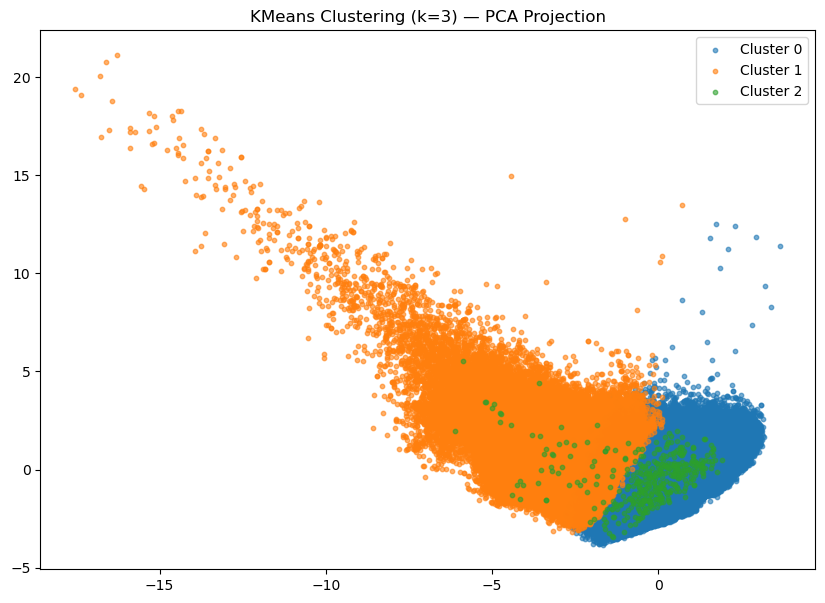

In [9]:
from pyspark.ml.feature import PCA
import pandas as pd
import matplotlib.pyplot as plt

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(df_clustered_3)
df_pca = pca_model.transform(df_clustered_3)

pdf = df_pca.select("pca_features", "prediction").sample(False, 0.25).toPandas()
pdf["PC1"] = pdf["pca_features"].apply(lambda x: x[0])
pdf["PC2"] = pdf["pca_features"].apply(lambda x: x[1])

plt.figure(figsize=(10,7))
for c in sorted(pdf["prediction"].unique()):
    subset = pdf[pdf["prediction"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.6, label=f"Cluster {c}")

plt.title("KMeans Clustering (k=3) — PCA Projection")
plt.legend()
plt.show()


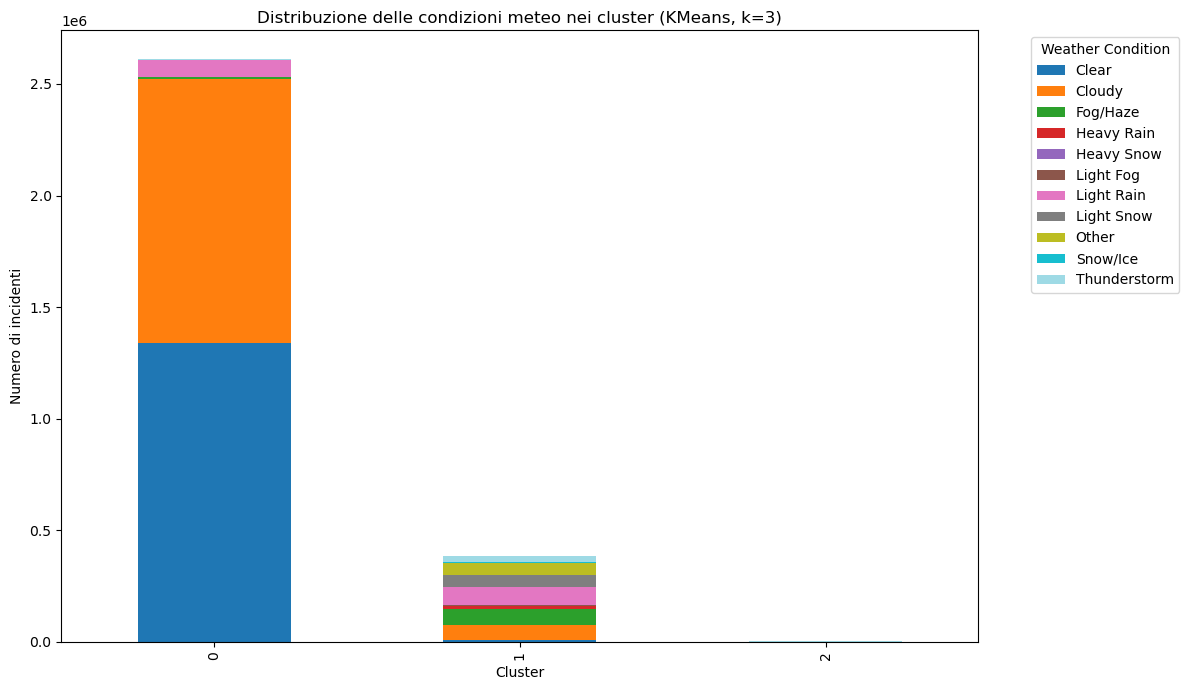

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_clustered_3.select("prediction", "weather_grouped").toPandas()

pivot = pd.crosstab(
    df_plot["prediction"],
    df_plot["weather_grouped"]
)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7),
    colormap="tab20"
)

plt.title("Distribuzione delle condizioni meteo nei cluster (KMeans, k=3)")
plt.xlabel("Cluster")
plt.ylabel("Numero di incidenti")
plt.legend(title="Weather Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [11]:
from pyspark.sql import functions as F

df_clustered_3.groupBy("prediction").agg(
    F.mean("Severity").alias("mean_severity"),
    F.mean("duration_min").alias("mean_duration_min"),
    F.mean("Hour").alias("mean_hour"),
    F.min("duration_min").alias("min_duration_min"),
    F.max("duration_min").alias("max_duration_min")
).show()


+----------+------------------+------------------+------------------+------------------+------------------+
|prediction|     mean_severity| mean_duration_min|         mean_hour|  min_duration_min|  max_duration_min|
+----------+------------------+------------------+------------------+------------------+------------------+
|         2|2.2258477287268073| 547804.9427703135|12.669865642994242|          275803.9|         2812999.0|
|         0| 2.210222180842769|133.73106950688393|  12.5060392928558|0.4666666666666667| 272208.0833333333|
|         1|2.2402282623927587|122.33416228532296| 11.12157645336918|               2.0|226081.78333333333|
+----------+------------------+------------------+------------------+------------------+------------------+



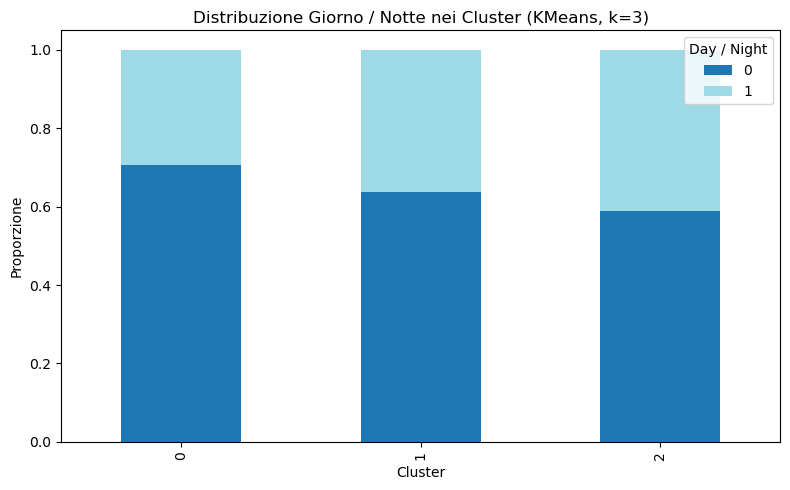

In [ ]:

# STACKED BAR: Giorno / Notte 
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt


df_dn = (
    df_clustered_3
    .groupBy("prediction", "Sunrise_Sunset")
    .count()
)


window_cluster = Window.partitionBy("prediction")

df_dn_norm = (
    df_dn
    .withColumn(
        "prop",
        F.col("count") / F.sum("count").over(window_cluster)
    )
)


pdf_dn = df_dn_norm.toPandas()


pivot_dn = pdf_dn.pivot(
    index="prediction",
    columns="Sunrise_Sunset",
    values="prop"
)


pivot_dn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="tab20"
)

plt.title("Distribuzione Giorno / Notte nei Cluster (KMeans, k=3)")
plt.xlabel("Cluster")
plt.ylabel("Proporzione")
plt.legend(title="Day / Night")
plt.tight_layout()
plt.show()


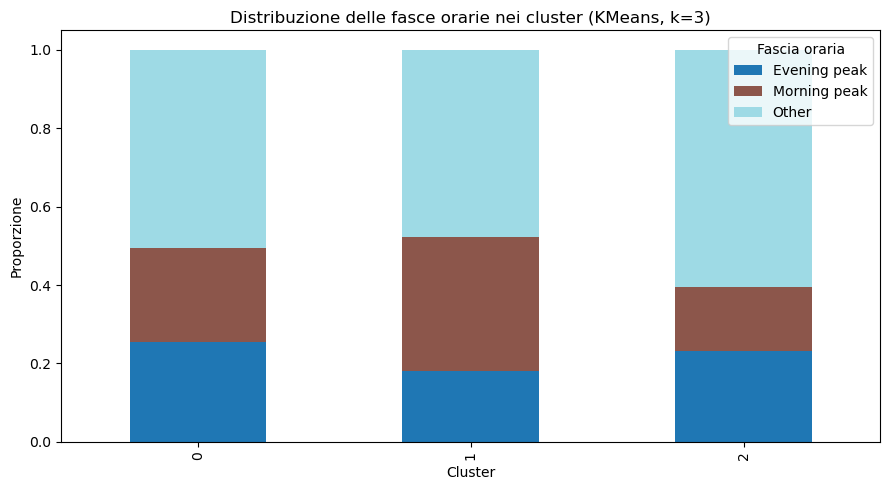

In [13]:

# STACKED BAR: Fasce orarie 

from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

df_hour = (
    df_clustered_3
    .withColumn(
        "hour_bin",
        F.when(F.col("Hour").between(6, 9), "Morning peak")
         .when(F.col("Hour").between(16, 19), "Evening peak")
         .otherwise("Other")
    )
)

df_hour_agg = (
    df_hour
    .groupBy("prediction", "hour_bin")
    .count()
)


window_cluster = Window.partitionBy("prediction")

df_hour_norm = (
    df_hour_agg
    .withColumn(
        "prop",
        F.col("count") / F.sum("count").over(window_cluster)
    )
)


pdf_hour = df_hour_norm.toPandas()

pivot_hour = pdf_hour.pivot(
    index="prediction",
    columns="hour_bin",
    values="prop"
)


pivot_hour.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    colormap="tab20"
)

plt.title("Distribuzione delle fasce orarie nei cluster (KMeans, k=3)")
plt.xlabel("Cluster")
plt.ylabel("Proporzione")
plt.legend(title="Fascia oraria")
plt.tight_layout()
plt.show()


In [14]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(featuresCol="features")

score_kmeans = evaluator.evaluate(df_clustered_3)

print("Silhouette score (KMeans, k=3):", score_kmeans)


Silhouette score (KMeans, k=3): 0.48619710694655865


# bisecting k means

In [15]:
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler

indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in cat_cols
]

assembler = VectorAssembler(
    inputCols=num_cols + [c+"_idx" for c in cat_cols],
    outputCol="unscaled_features"
)

scaler = StandardScaler(
    inputCol="unscaled_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

bkm = BisectingKMeans(k=3, seed=42, featuresCol="features")

pipeline_bkm = Pipeline(stages=indexers + [assembler, scaler, bkm])

bkm_model = pipeline_bkm.fit(df_sample)
df_bkm_3 = bkm_model.transform(df_sample)

df_bkm_3.groupBy("prediction").count().show()


+----------+-------+
|prediction|  count|
+----------+-------+
|         2|1093713|
|         1| 961070|
|         0| 942117|
+----------+-------+



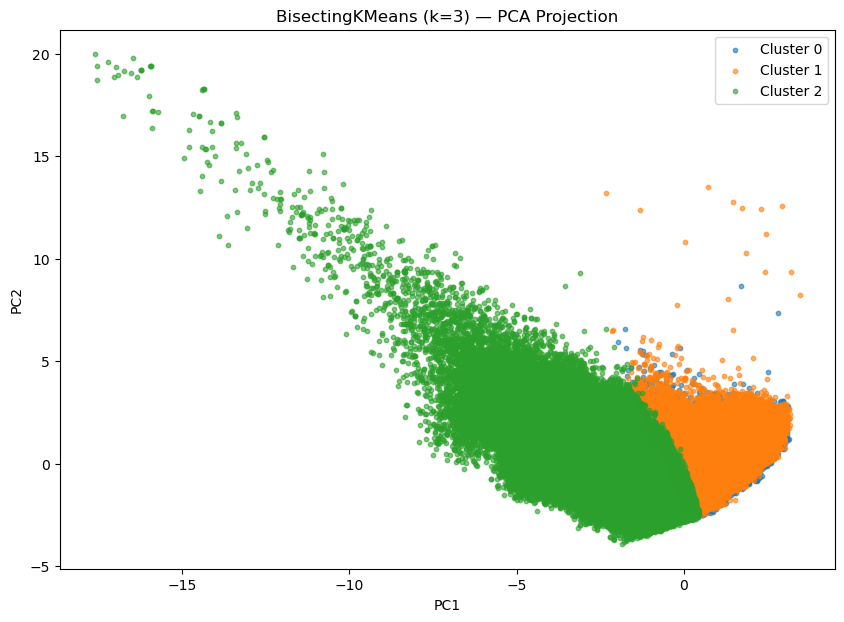

In [16]:

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(df_bkm_3)
df_pca_bkm = pca_model.transform(df_bkm_3)

pdf_bkm = (
    df_pca_bkm
    .select("pca_features", "prediction")
    .sample(False, 0.25)
    .toPandas()
)

pdf_bkm["PC1"] = pdf_bkm["pca_features"].apply(lambda x: x[0])
pdf_bkm["PC2"] = pdf_bkm["pca_features"].apply(lambda x: x[1])

plt.figure(figsize=(10,7))
for c in sorted(pdf_bkm["prediction"].unique()):
    subset = pdf_bkm[pdf_bkm["prediction"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.6, label=f"Cluster {c}")

plt.title("BisectingKMeans (k=3) — PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


C:\Users\Win10\AppData\Local\Temp\ipykernel_14104\1361326061.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


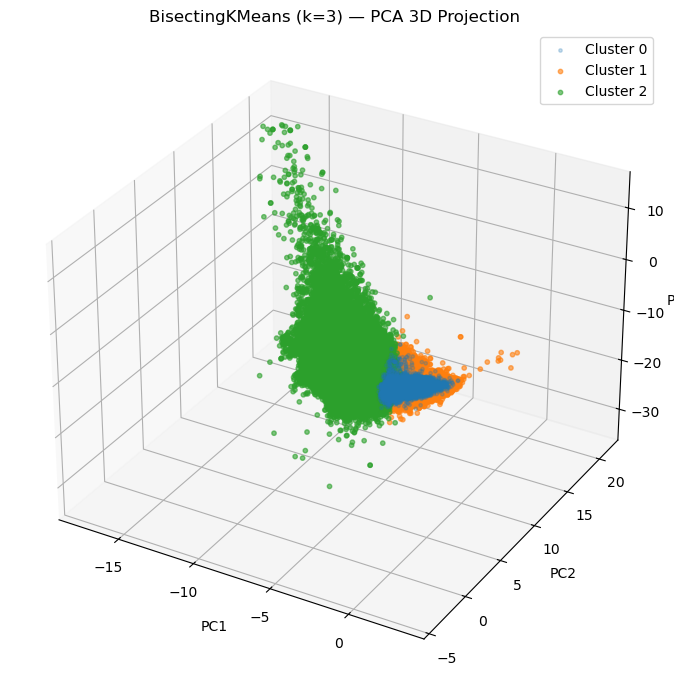

In [17]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd


pca = PCA(k=3, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(df_bkm_3)
df_pca_bkm = pca_model.transform(df_bkm_3)


pdf_bkm = (
    df_pca_bkm
    .select("pca_features", "prediction")
    .sample(False, 0.25, seed=42)
    .toPandas()
)


pdf_bkm["PC1"] = pdf_bkm["pca_features"].apply(lambda x: x[0])
pdf_bkm["PC2"] = pdf_bkm["pca_features"].apply(lambda x: x[1])
pdf_bkm["PC3"] = pdf_bkm["pca_features"].apply(lambda x: x[2])


pdf_plot = pd.concat([
    pdf_bkm[pdf_bkm["prediction"] == 0].sample(6000, random_state=42),
    pdf_bkm[pdf_bkm["prediction"] == 1],
    pdf_bkm[pdf_bkm["prediction"] == 2]
])


fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

for c in sorted(pdf_plot["prediction"].unique()):
    subset = pdf_plot[pdf_plot["prediction"] == c]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        s=10 if c != 0 else 6,
        alpha=0.6 if c != 0 else 0.25,
        label=f"Cluster {c}"
    )

ax.set_title("BisectingKMeans (k=3) — PCA 3D Projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.tight_layout()
plt.show()


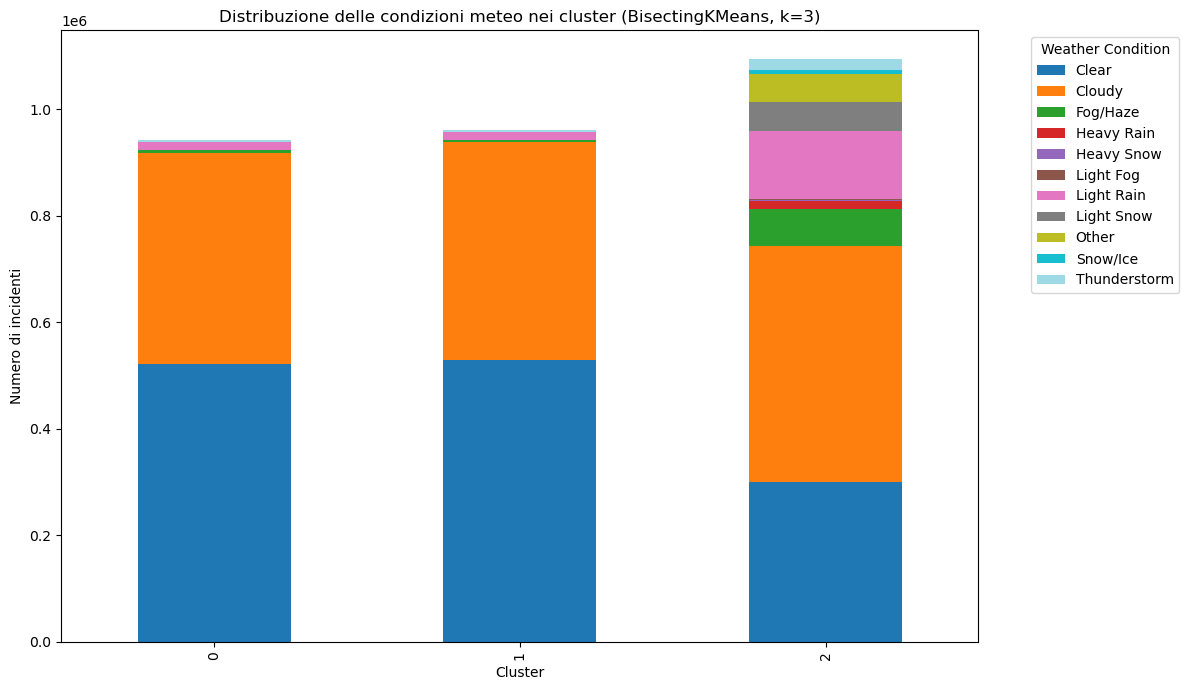

In [18]:
df_plot_bkm = df_bkm_3.select("prediction", "weather_grouped").toPandas()

pivot_bkm = pd.crosstab(
    df_plot_bkm["prediction"],
    df_plot_bkm["weather_grouped"]
)

pivot_bkm.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7),
    colormap="tab20"
)

plt.title("Distribuzione delle condizioni meteo nei cluster (BisectingKMeans, k=3)")
plt.xlabel("Cluster")
plt.ylabel("Numero di incidenti")
plt.legend(title="Weather Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## confronta tra bisecting kmeans e kmeans

In [19]:
score_bkm = evaluator.evaluate(df_bkm_3)

print("Silhouette score (KMeans, k=3):", score_kmeans)
print("Silhouette score (BisectingKMeans, k=3):", score_bkm)


Silhouette score (KMeans, k=3): 0.48619710694655865
Silhouette score (BisectingKMeans, k=3): 0.03323332226375488


## analisi geografica e mappe

In [20]:
df_geo = (
    df_clustered_3
    .groupBy("prediction", "State")
    .count()
    .orderBy("prediction", "count", ascending=False)
)

df_geo.show(60)


+----------+-----+-----+
|prediction|State|count|
+----------+-----+-----+
|         2|   LA| 1401|
|         2|   OR|   46|
|         2|   NV|   22|
|         2|   DE|   21|
|         2|   PA|   11|
|         2|   NC|    8|
|         2|   AZ|    7|
|         2|   NY|    7|
|         2|   NJ|    6|
|         2|   CA|    6|
|         2|   IN|    6|
|         2|   MS|    3|
|         2|   IA|    3|
|         2|   TX|    3|
|         2|   VA|    2|
|         2|   KS|    2|
|         2|   SC|    2|
|         2|   OH|    2|
|         2|   MD|    2|
|         2|   TN|    1|
|         2|   IL|    1|
|         2|   MI|    1|
|         1|   CA|68917|
|         1|   FL|27782|
|         1|   TX|23066|
|         1|   NY|21412|
|         1|   PA|20598|
|         1|   MN|19351|
|         1|   SC|18085|
|         1|   NC|15587|
|         1|   VA|13946|
|         1|   MI|13901|
|         1|   OR|12344|
|         1|   IL|11110|
|         1|   OH|10040|
|         1|   GA| 9240|
|         1|   NJ| 8747|


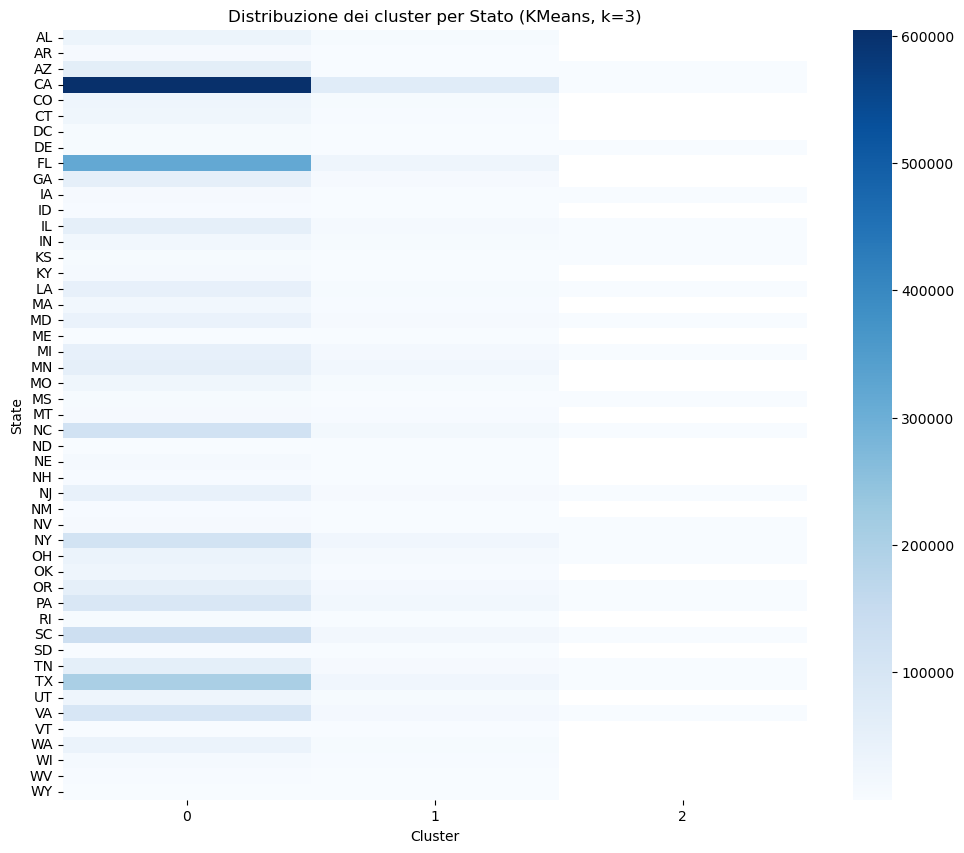

In [21]:
import seaborn as sns

pdf_geo = df_geo.toPandas().pivot(
    index="State",
    columns="prediction",
    values="count"
)

plt.figure(figsize=(12,10))
sns.heatmap(pdf_geo, cmap="Blues", annot=False)
plt.title("Distribuzione dei cluster per Stato (KMeans, k=3)")
plt.xlabel("Cluster")
plt.ylabel("State")
plt.show()


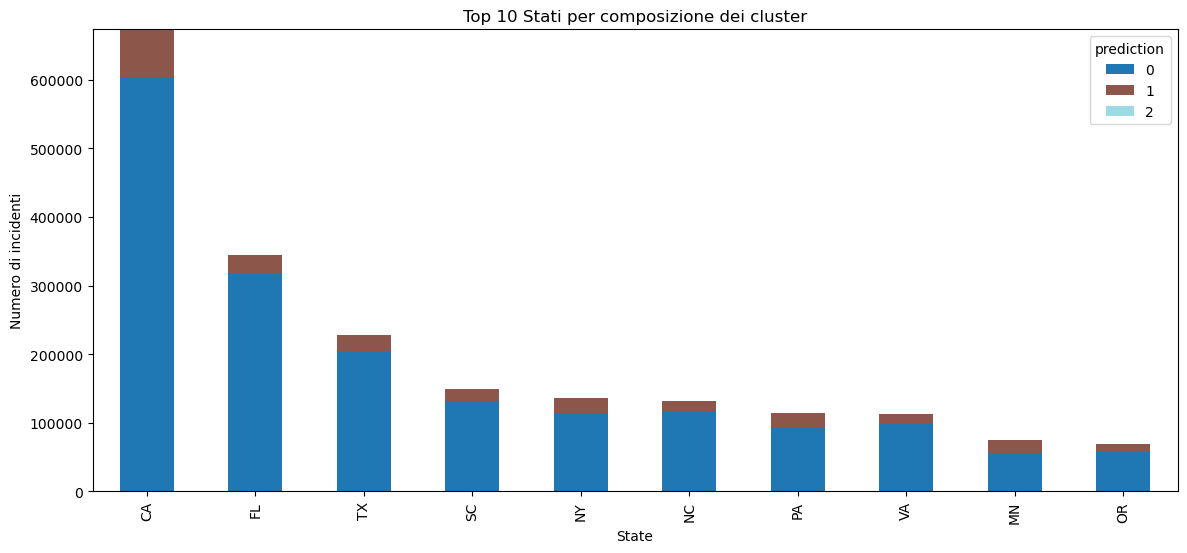

In [22]:
pdf_top_states = (
    pdf_geo
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

pdf_geo_top = pdf_geo.loc[pdf_top_states]

pdf_geo_top.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6),
    colormap="tab20"
)

plt.title("Top 10 Stati per composizione dei cluster")
plt.xlabel("State")
plt.ylabel("Numero di incidenti")
plt.show()


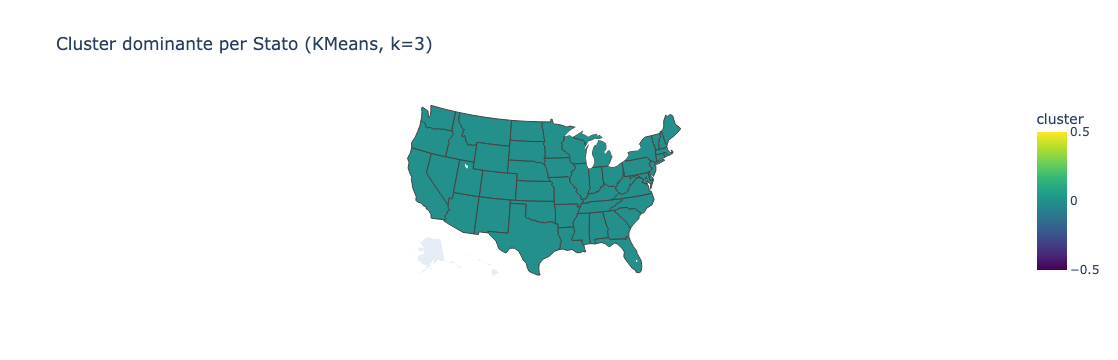

In [23]:
import plotly.express as px

pdf_dom = pdf_geo.idxmax(axis=1).reset_index()
pdf_dom.columns = ["State", "cluster"]

fig = px.choropleth(
    pdf_dom,
    locations="State",
    locationmode="USA-states",
    color="cluster",
    scope="usa",
    title="Cluster dominante per Stato (KMeans, k=3)",
    color_continuous_scale="Viridis"
)

fig.show()


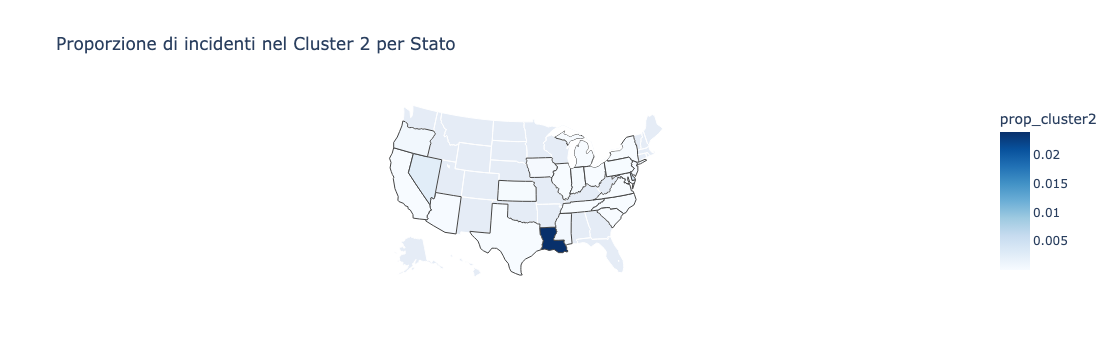

In [24]:
pdf_prop = (pdf_geo[2] / pdf_geo.sum(axis=1)).reset_index()
pdf_prop.columns = ["State", "prop_cluster2"]

fig = px.choropleth(
    pdf_prop,
    locations="State",
    locationmode="USA-states",
    color="prop_cluster2",
    scope="usa",
    title="Proporzione di incidenti nel Cluster 2 per Stato",
    color_continuous_scale="Blues"
)

fig.show()


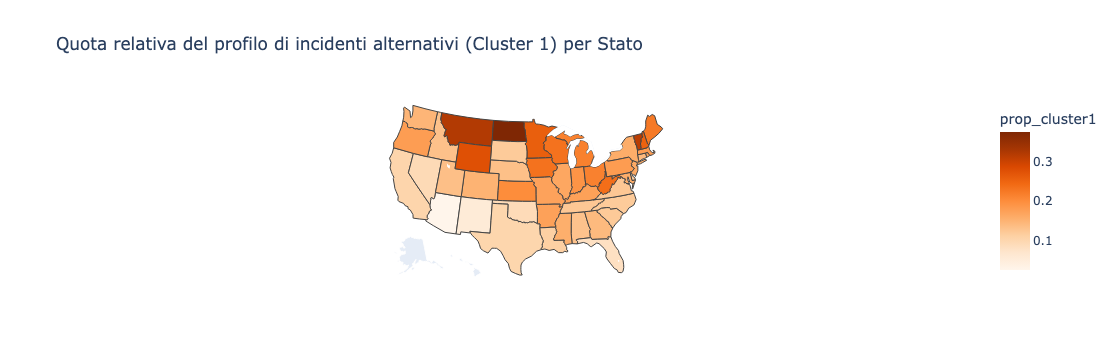

In [25]:
pdf_prop1 = (pdf_geo[1] / pdf_geo.sum(axis=1)).reset_index()
pdf_prop1.columns = ["State", "prop_cluster1"]

fig = px.choropleth(
    pdf_prop1,
    locations="State",
    locationmode="USA-states",
    color="prop_cluster1",
    scope="usa",
    title="Quota relativa del profilo di incidenti alternativi (Cluster 1) per Stato",
    color_continuous_scale="Oranges"
)
fig.show()
